<a href="https://colab.research.google.com/github/icosahedron31/Walmart-Sales/blob/main/TFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wandb onnx -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 45.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Imports**

In [ ]:
!pip install pytorch_forecasting -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 63.8 MB/s eta 0:00:00


In [ ]:


import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np
import pandas as pd
import torch
import json


In [ ]:
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer

**WandB**

In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tdola23 (tdola23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
!ls /content/drive/MyDrive

**Data Processing**

In [ ]:
full_df = pd.read_csv("/content/drive/MyDrive/WalmartPrices/full.csv")

In [ ]:
test_horizon = 35
full_dates = pd.to_datetime(full_df['Date']).sort_values().unique()
last_available_date = full_dates[-1]

# validation should end at last_available_date, and start 35 weeks before that
val_end_date = last_available_date
val_start_date = val_end_date - pd.Timedelta(weeks=test_horizon - 1)

print("New val range:", val_start_date, "to", val_end_date)

New val range: 2012-03-02 00:00:00 to 2012-10-26 00:00:00


In [ ]:
import sys

# Replace 'your_folder_name' with the actual path to the directory containing your Python file
# For example, if 'HolidayProximityTransformer.py' is directly in 'My Drive',
# the path would be '/content/drive/MyDrive'
# If it's in a subfolder like 'My Drive/my_project',
# the path would be '/content/drive/MyDrive/my_project'
directory_path = '/content/drive/MyDrive/WalmartPrices/'

# Add the directory to sys.path
if directory_path not in sys.path:
    sys.path.append(directory_path)

print(f"Added '{directory_path}' to sys.path.")

Added '/content/drive/MyDrive/WalmartPrices/' to sys.path.


**Train/Val split**

In [ ]:
full_df['Date'] = pd.to_datetime(full_df['Date'])

train_df = full_df[full_df['Date'] < val_start_date].copy()
val_df = full_df[full_df['Date'] >= val_start_date].copy()
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    421570 non-null  int64         
 1   Store         421570 non-null  int64         
 2   Dept          421570 non-null  int64         
 3   Date          421570 non-null  datetime64[ns]
 4   Weekly_Sales  421570 non-null  float64       
 5   IsHoliday_x   421570 non-null  bool          
 6   Week          421570 non-null  int64         
 7   Month         421570 non-null  int64         
 8   Year          421570 non-null  int64         
 9   Temperature   421570 non-null  float64       
 10  Fuel_Price    421570 non-null  float64       
 11  MarkDown1     150681 non-null  float64       
 12  MarkDown2     111248 non-null  float64       
 13  MarkDown3     137091 non-null  float64       
 14  MarkDown4     134967 non-null  float64       
 15  MarkDown5     151

**Preprocessing**

In [ ]:
from HolidayEngineer import HolidayProximityTransformer
from calendar_features import calendar_feature_engineer
from EconomicIndicatorImputer import EconomicIndicatorImputer
from MarkdownImputer import MarkdownImputer
from CategoryConverter import CategoryConverter


In [ ]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class ConvertToCategorical(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns or ['Store', 'Dept', 'IsHoliday_x', 'Type']

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = list(self.columns)

        missing = set(self.columns_) - set(X.columns)
        if missing:
            raise ValueError(f"Missing expected columns: {missing}")

        self.categories_ = {
            col: pd.Series(X[col].astype(str).unique()).sort_values().tolist()
            for col in self.columns_
        }
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.columns_:
            X[col] = pd.Categorical(X[col].astype(str), categories=self.categories_[col])
        return X

In [ ]:
class DateToTimeIdx(BaseEstimator, TransformerMixin):

    def __init__(self, date_col='Date', time_idx_col='time_idx'):
        self.date_col = date_col
        self.time_idx_col = time_idx_col

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        dates = pd.to_datetime(X[self.date_col])
        self.min_date_ = dates.min()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X[self.date_col] = pd.to_datetime(X[self.date_col])

        delta_days = (X[self.date_col] - self.min_date_).dt.days
        X[self.time_idx_col] = (delta_days // 7).astype(int)

        return X


In [ ]:
class WeightMetric(BaseEstimator, TransformerMixin):


    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X["wmae_weight"] = np.where(X["IsHoliday_x"], 5.0, 1.0)

        return X


In [ ]:
class DropColumn(BaseEstimator, TransformerMixin):

    def __init__(self, drop_cols=None):
        self.drop_cols = drop_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.drop(columns=self.drop_cols, inplace=True)

        return X


In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    421570 non-null  int64         
 1   Store         421570 non-null  int64         
 2   Dept          421570 non-null  int64         
 3   Date          421570 non-null  datetime64[ns]
 4   Weekly_Sales  421570 non-null  float64       
 5   IsHoliday_x   421570 non-null  bool          
 6   Week          421570 non-null  int64         
 7   Month         421570 non-null  int64         
 8   Year          421570 non-null  int64         
 9   Temperature   421570 non-null  float64       
 10  Fuel_Price    421570 non-null  float64       
 11  MarkDown1     150681 non-null  float64       
 12  MarkDown2     111248 non-null  float64       
 13  MarkDown3     137091 non-null  float64       
 14  MarkDown4     134967 non-null  float64       
 15  MarkDown5     151

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('holiday_engineer', HolidayProximityTransformer()),
    ('calendar_feature_engineer', calendar_feature_engineer()),
    ('economic_indicator_imputer', EconomicIndicatorImputer()),
    ('markdown_imputer', MarkdownImputer()),
   ('to_categorical', ConvertToCategorical()),
    ('Date_processor', DateToTimeIdx()),
    ('drop_holiday', DropColumn(drop_cols=['IsHoliday_y', 'year', 'month', 'week', 'Week', 'Year', 'Month', 'Week', 'quarter'])),
    ('wmae_metric', WeightMetric())

])
train_df_t = pipe.fit_transform(train_df)
val_df_t = pipe.transform(val_df)
train_df_t.info()
val_df_t.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317928 entries, 0 to 421534
Data columns (total 35 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Unnamed: 0                317928 non-null  int64         
 1   Store                     317928 non-null  category      
 2   Dept                      317928 non-null  category      
 3   Date                      317928 non-null  datetime64[ns]
 4   Weekly_Sales              317928 non-null  float64       
 5   IsHoliday_x               317928 non-null  category      
 6   Temperature               317928 non-null  float64       
 7   Fuel_Price                317928 non-null  float64       
 8   MarkDown1                 317928 non-null  float64       
 9   MarkDown2                 317928 non-null  float64       
 10  MarkDown3                 317928 non-null  float64       
 11  MarkDown4                 317928 non-null  float64       
 12  MarkDow

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


**Creating Dataset**

In [ ]:
from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer

max_encoder_length = 52
max_prediction_length = 35

holiday_reals = [
    "weeks_to_super_bowl", "weeks_since_super_bowl", "super_bowl_phase_sin", "super_bowl_phase_cos",
    "weeks_to_labor_day", "weeks_since_labor_day", "labor_day_phase_sin", "labor_day_phase_cos",
    "weeks_to_thanksgiving", "weeks_since_thanksgiving", "thanksgiving_phase_sin", "thanksgiving_phase_cos",
    "weeks_to_christmas", "weeks_since_christmas", "christmas_phase_sin", "christmas_phase_cos",
]

training = TimeSeriesDataSet(
    train_df_t,
    time_idx="time_idx",
    target="Weekly_Sales",
    group_ids=["Store", "Dept"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=["Store", "Dept", "Type"],
    static_reals=["Size"],

    time_varying_known_categoricals=["IsHoliday_x"],
    time_varying_known_reals=[
        "time_idx",
        "Temperature", "Fuel_Price", "CPI", "Unemployment",
        "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    ] + holiday_reals,

    time_varying_unknown_reals=["Weekly_Sales"],
    weight="wmae_weight",
    target_normalizer=GroupNormalizer(
        groups=["Store", "Dept"]
    ),

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,

    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    pd.concat([train_df_t, val_df_t], axis=0).reset_index(drop=True),
    predict=True,
    stop_randomization=True,
)

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 293 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__Store': '1', '__group_id__Dept': '51'}, {'__group_id__Store': '1', '__group_id__Dept': '77'}, {'__group_id__Store': '1', '__group_id__Dept': '78'}, {'__group_id__Store': '10', '__group_id__Dept': '51'}, {'__group_id__Store': '10', '__group_id__Dept': '77'}, {'__group_id__Store': '11', '__group_id__Dept': '48'}, {'__group_id__Store': '11', '__group_id__Dept': '50'}, {'__group_id__Store': '11', '__group_id__Dept': '51'}, {'__group_id__Store': '11', '__group_id__Dept': '77'}, {'__group_id__Store': '11', '__group_id__Dept': '78'}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/tim

In [ ]:
val_df_t.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103642 entries, 108 to 421569
Data columns (total 35 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Unnamed: 0                103642 non-null  int64         
 1   Store                     103642 non-null  category      
 2   Dept                      103642 non-null  category      
 3   Date                      103642 non-null  datetime64[ns]
 4   Weekly_Sales              103642 non-null  float64       
 5   IsHoliday_x               103642 non-null  category      
 6   Temperature               103642 non-null  float64       
 7   Fuel_Price                103642 non-null  float64       
 8   MarkDown1                 103642 non-null  float64       
 9   MarkDown2                 103642 non-null  float64       
 10  MarkDown3                 103642 non-null  float64       
 11  MarkDown4                 103642 non-null  float64       
 12  MarkD

In [ ]:
train_loader = training.to_dataloader(train=True, batch_size=128, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=128, num_workers=0)

**Loss**

In [ ]:
# WMAE metric
import numpy as np

def WMAE(y_true, y_pred, is_holiday):
    is_holiday_bool = is_holiday.astype(str).str.lower().isin(["true"])
    weights = np.where(is_holiday_bool, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

**Baseline**

In [ ]:
from pytorch_forecasting import Baseline

baseline_predictions = Baseline().predict(
    val_loader,
    return_x=True,
    return_y=True,
    return_index=True,
)

y_pred = baseline_predictions.output.cpu()
y_true = baseline_predictions.y[0].cpu()
index_df = baseline_predictions.index  # already a dataframe with Store, Dept, time_idx per row

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightnin

In [ ]:
y_pred.shape, y_true.shape, index_df.shape

(torch.Size([2947, 35]), torch.Size([2947, 35]), (2947, 3))

In [ ]:
import numpy as np
import pandas as pd

# y_pred, y_true shape: (num_samples, prediction_length)
pred_len = y_pred.shape[1]

# Repeat each index row pred_len times, and add offset 0..pred_len-1 to time_idx
index_expanded = index_df.loc[index_df.index.repeat(pred_len)].reset_index(drop=True)
index_expanded["time_idx"] = (
    index_expanded["time_idx"].values
    + np.tile(np.arange(pred_len), len(index_df))
)

# Flatten predictions/targets to match row-by-row
index_expanded["y_pred"] = y_pred.numpy().flatten()
index_expanded["y_true"] = y_true.numpy().flatten()
full_df = pd.concat([train_df_t, val_df_t], axis=0).reset_index(drop=True)

# Now merge with your full dataset on the keys + time_idx
print(index_expanded.shape)
merged = index_expanded.merge(
    full_df,
    on=["Store", "Dept", "time_idx"],
    how="inner"   # or "inner" if you only want rows that have predictions
)
merged.info()

(103145, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100795 entries, 0 to 100794
Data columns (total 37 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   time_idx                  100795 non-null  int64         
 1   Store                     100795 non-null  object        
 2   Dept                      100795 non-null  object        
 3   y_pred                    100795 non-null  float32       
 4   y_true                    100795 non-null  float32       
 5   Unnamed: 0                100795 non-null  int64         
 6   Date                      100795 non-null  datetime64[ns]
 7   Weekly_Sales              100795 non-null  float64       
 8   IsHoliday_x               100795 non-null  category      
 9   Temperature               100795 non-null  float64       
 10  Fuel_Price                100795 non-null  float64       
 11  MarkDown1                 100795 non-null  float64   

In [ ]:
print(merged["y_true"].isna().sum())
print(merged["y_pred"].isna().sum())
print(merged["IsHoliday_x"].isna().sum())
print(len(merged))

0
0
0
100795


In [ ]:
wmae = WMAE(merged["y_true"], merged["y_pred"], merged["IsHoliday_x"])
print(f"WMAE: {wmae}")

WMAE: 2801.958783269697


**LR Finding**

In [ ]:
# configure network and trainer

from pytorch_forecasting.metrics import MAE
pl.seed_everything(42)
trainer = pl.Trainer(
    accelerator="cpu",

    gradient_clip_val=0.1,
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    # not meaningful for finding the learning rate but otherwise very important
    learning_rate=0.03,
    hidden_size=64,  # most important hyperparameter apart from learning rate
    # number of attention heads. Set to up to 4 for large datasets
    attention_head_size=1,
    dropout=0.1,  # between 0.1 and 0.3 are good values
    hidden_continuous_size=8,  # set to <= hidden_size
    loss=MAE(),
    optimizer="ranger",
    # reduce learning rate if no improvement in validation loss after x epochs
    # reduce_on_plateau_patience=1000,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointi

Number of parameters in network: 334.5k


In [ ]:
!pip install pytorch_optimizer

In [ ]:
import torch

_orig_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _orig_load(*args, **kwargs)
torch.load = _patched_load

In [ ]:
# find optimal learning rate
from lightning.pytorch.tuner import Tuner

res = Tuner(trainer).lr_find(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    max_lr=2.0,
    min_lr=1e-6,
)

print(f"suggested learning rate: {res.suggestion()}")
fig = res.plot(show=True, suggest=True)
fig.show()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: `weights_only` was not set, defaulting to `False`.
INFO:lightning.pytorch.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_steps=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO: Restoring states from the checkpoint path at /content/.lr_find_c40431b5-269f-4e78-adf1-7b6e0e0080ae.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_c40431b5-269f-4e78-adf1-7b6e0e0080ae.ckpt


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pytorch_forecasting.data.encoders.GroupNormalizer was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pytorch_forecasting.data.encoders.GroupNormalizer])` or the `torch.serialization.safe_globals([pytorch_forecasting.data.encoders.GroupNormalizer])` context manager to allowlist this global if you trust this clas

**Training**

In [ ]:
!pip install pytorch_optimizer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.8/300.8 kB 10.6 MB/s eta 0:00:00


In [ ]:
import torch

_original_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return _original_load(*args, **kwargs)
torch.load = _patched_load

In [ ]:
!pip install optuna optuna-integration[wandb] wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 12.1 MB/s eta 0:00:00


**Feature Importances**

In [ ]:
import torch
import lightning.pytorch as pl


class WMAECallback(pl.Callback):
    def __init__(self):
        super().__init__()
        self.num = []
        self.den = []

    def on_validation_batch_end(
        self, trainer, pl_module, outputs, batch, batch_idx, dataloader_idx=0
    ):
        x, y = batch
        target = y[0]

        # weight comes from weight="wmae_weight" on the dataset; may be None
        weights = y[1] if (len(y) > 1 and y[1] is not None) else torch.ones_like(target)

        with torch.no_grad():
            out = pl_module(x)
        pred = pl_module.to_prediction(out)   # point (median) forecast, scale handled by lib

        weights = weights.to(pred)
        target = target.to(pred)

        self.num.append((weights * (pred - target).abs()).sum().detach())
        self.den.append(weights.sum().detach())

    def on_validation_epoch_end(self, trainer, pl_module):
        score = torch.stack(self.num).sum() / torch.stack(self.den).sum()
        pl_module.log("val_wmae", score, prog_bar=True, logger=True)
        self.num.clear()
        self.den.clear()

In [ ]:
!pip install optuna statsmodels optuna-integration

In [ ]:
type(val_df_t["IsHoliday_x"].iloc[0])

In [ ]:
import torch
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import lightning.pytorch as pl
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss


def ranked(importance_tensor, names):
    s = pd.Series(importance_tensor.detach().cpu().numpy(), index=names)
    return (s / s.sum()).sort_values(ascending=False)   # normalized fractions


def log_importance(tag, imp_series):
    """Log a ranked importance series to wandb as both a bar chart and a table."""
    table = wandb.Table(
        columns=["feature", "importance"],
        data=[[f, float(v)] for f, v in imp_series.items()],
    )
    wandb.log({
        f"{tag}_bar": wandb.plot.bar(table, "feature", "importance", title=tag),
        f"{tag}_table": table,
    })

In [ ]:
import torch
import wandb
import lightning.pytorch as pl
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss, MAE

# ── one model, fixed hyperparameters (no search) ──────────────────────────
# Values are reasonable mid-range defaults. Importance ranking is not very
# sensitive to these — you just need a model that trains stably.
model = TemporalFusionTransformer.from_dataset(
    training,
    hidden_size=64,
    hidden_continuous_size=32,
    dropout=0.2,
    learning_rate=1e-4,
    loss=MAE(),
)

wandb_logger = WandbLogger(
    project="walmart-sales-forecasting",
    group="feature_importance_tft",
    name="importance_run_2",
    log_model=False,
)

# ~20 epochs so holiday structure is actually learned before we read importances.
# early stopping still caps it if val_wmae plateaus.
trainer = pl.Trainer(
    max_epochs=20,
    gradient_clip_val=0.1,
    callbacks=[
        WMAECallback(),
        EarlyStopping(monitor="val_wmae", mode="min", patience=6),
    ],
    logger=wandb_logger,
    enable_progress_bar=True,
)


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

In [ ]:
try:
    trainer.fit(model, train_loader, val_loader)

    # ── global importances ────────────────────────────────────────────────
    raw = model.predict(val_loader, mode="raw", return_x=True)
    interp = model.interpret_output(raw.output, reduction="sum")

    enc = ranked(interp["encoder_variables"], model.encoder_variables)
    dec = ranked(interp["decoder_variables"], model.decoder_variables)
    sta = ranked(interp["static_variables"], model.static_variables)

    log_importance("encoder_importance", enc)
    log_importance("decoder_importance", dec)
    log_importance("static_importance", sta)

    # also log the built-in interpretation figures as images
    figs = model.plot_interpretation(interp)   # returns dict of matplotlib figures
    wandb.log({f"interp_{k}": wandb.Image(v) for k, v in figs.items()})
    plt.close("all")

    # ── holiday-only importances (the weighted-weeks view) ────────────────
    val_holiday = val_df_t[val_df_t["IsHoliday_x"] == True].reset_index(drop=True)
    if len(val_holiday) > 0:
        holiday_ds = TimeSeriesDataSet.from_dataset(
            training, val_holiday, predict=False, stop_randomization=True
        )
        holiday_loader = holiday_ds.to_dataloader(train=False, batch_size=128, num_workers=2)

        raw_h = model.predict(holiday_loader, mode="raw", return_x=True)
        interp_h = model.interpret_output(raw_h.output, reduction="sum")
        enc_h = ranked(interp_h["encoder_variables"], training.encoder_variables)
        log_importance("encoder_importance_holiday", enc_h)

        # side-by-side delta: holiday minus global (positive = matters more on holidays)
        delta = (enc_h - enc).sort_values(ascending=False)
        log_importance("encoder_holiday_minus_global", delta)

    # keep the raw tables in the console too
    print("── ENCODER ──\n", enc, "\n── DECODER ──\n", dec, "\n── STATIC ──\n", sta)

finally:
    wandb.finish()

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  2.1 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.0 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 28.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  219 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  210 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     65 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 665 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 665 K                                                                                                
Total estimated model params size (MB): 2.662                                                                      
Modules in train mode: 1043                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇████
train_loss_epoch,█▅▄▃▃▂▂▂▁▁▁
train_loss_step,█▆█▆▅▅▅▅▄▃▃▄▆▂▃▄▁▃▃▃▄▄▃▃▃▄▂▂▃▂▄▃▄▄▃▂▁▁▂▃
trainer/global_step,▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
val_MAE,█▅▃▃▁▃▃▃▄▃▅
val_MAPE,█▇▇▇▇▆▅▅▃▁▁
val_RMSE,█▄▃▂▁▂▂▂▃▃▃
val_SMAPE,██▅▄▁▄▃▂▄▂▄
val_loss,█▅▃▃▁▃▃▃▄▃▅
val_wmae,█▅▃▃▁▃▃▃▄▃▅
epoch,10


AttributeError: 'TimeSeriesDataSet' object has no attribute 'encoder_variables'

In [ ]:
wandb.init(project='walmart-sales-forecasting', group='feature-importance-tft')
raw = model.predict(val_loader, mode="raw", return_x=True)
interp = model.interpret_output(raw.output, reduction="sum")

enc = ranked(interp["encoder_variables"], model.encoder_variables)
dec = ranked(interp["decoder_variables"], model.decoder_variables)
sta = ranked(interp["static_variables"], model.static_variables)

log_importance("encoder_importance", enc)
log_importance("decoder_importance", dec)
log_importance("static_importance", sta)

# also log the built-in interpretation figures as images
figs = model.plot_interpretation(interp)   # returns dict of matplotlib figures
wandb.log({f"interp_{k}": wandb.Image(v) for k, v in figs.items()})
plt.close("all")

# ── holiday-only importances (the weighted-weeks view) ────────────────
val_holiday = val_df_t[val_df_t["IsHoliday_x"] == True].reset_index(drop=True)
if len(val_holiday) > 0:
    holiday_ds = TimeSeriesDataSet.from_dataset(
        training, val_holiday, predict=False, stop_randomization=True
    )
    holiday_loader = holiday_ds.to_dataloader(train=False, batch_size=128, num_workers=2)

    raw_h = model.predict(holiday_loader, mode="raw", return_x=True)
    interp_h = model.interpret_output(raw_h.output, reduction="sum")
    enc_h = ranked(interp_h["encoder_variables"], training.encoder_variables)
    log_importance("encoder_importance_holiday", enc_h)

        # side-by-side delta: holiday minus global (positive = matters more on holidays)
    delta = (enc_h - enc).sort_values(ascending=False)
    log_importance("encoder_holiday_minus_global", delta)

    # keep the raw tables in the console too
    print("── ENCODER ──\n", enc, "\n── DECODER ──\n", dec, "\n── STATIC ──\n", sta)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

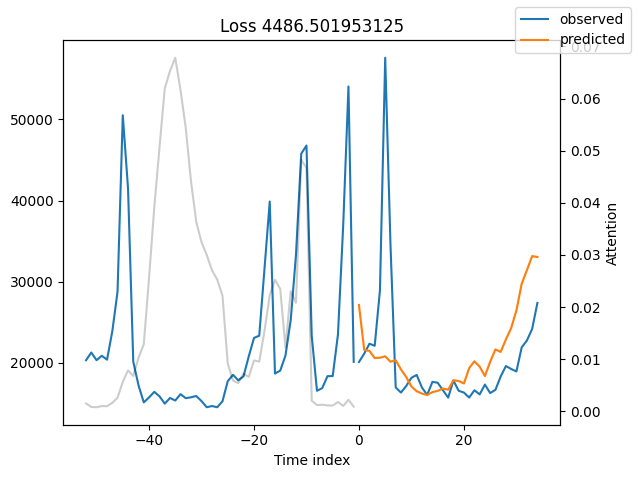

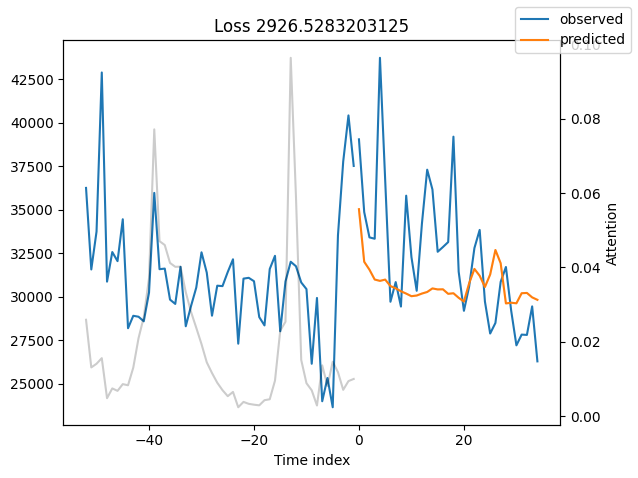

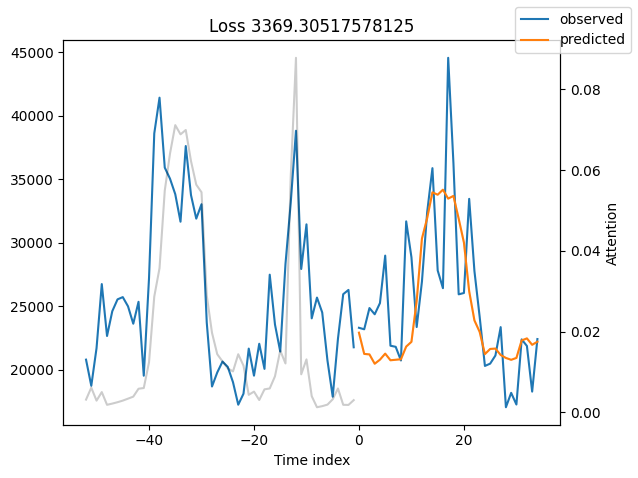

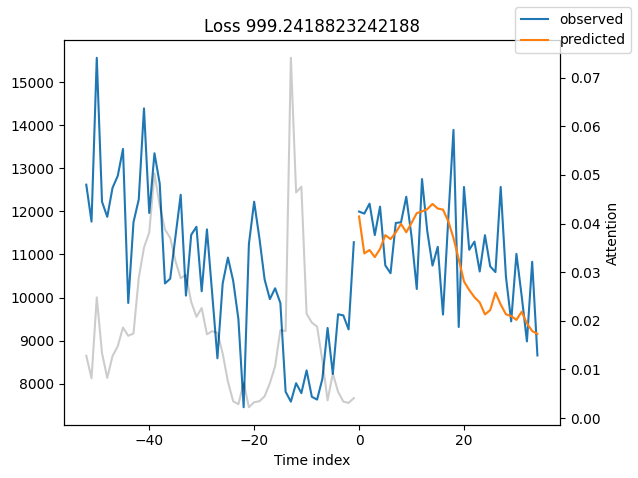

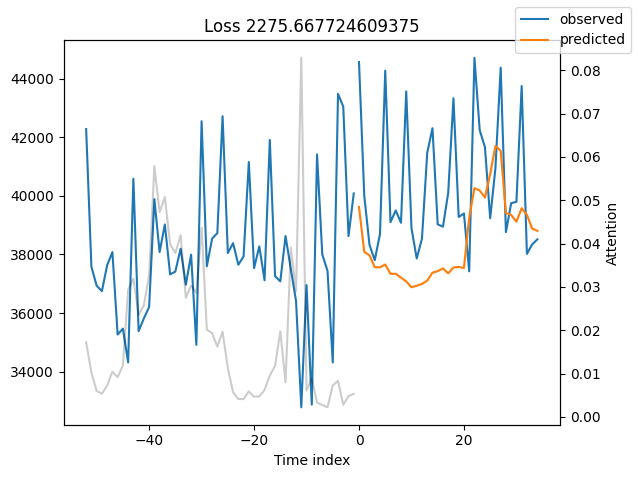

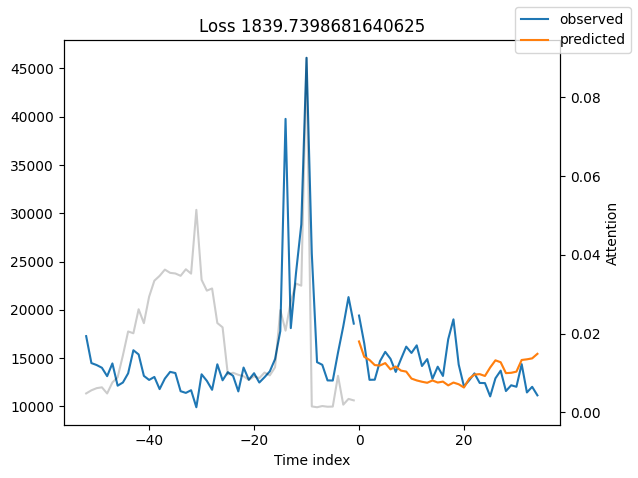

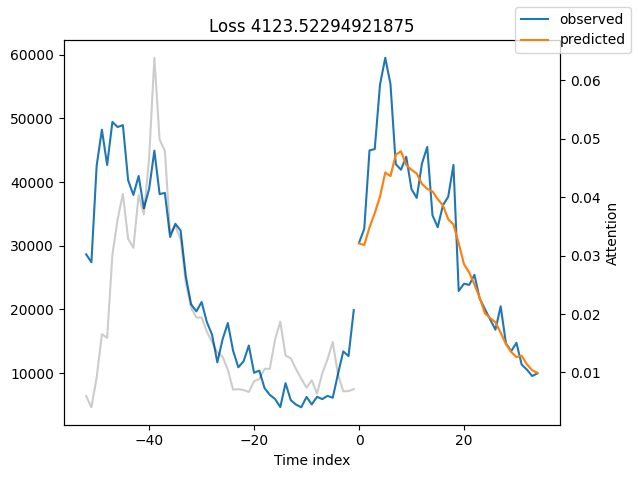

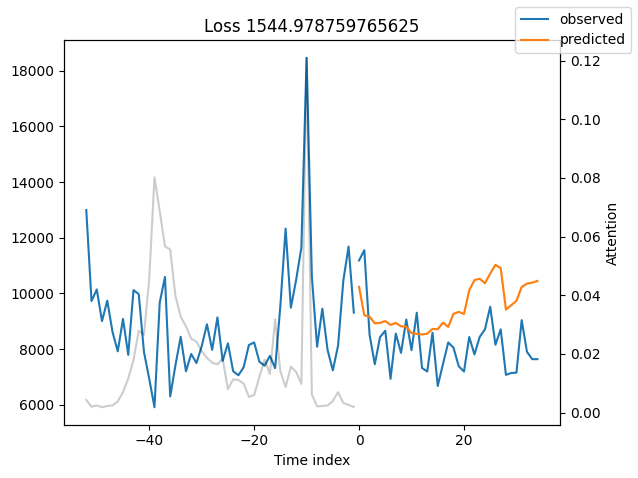

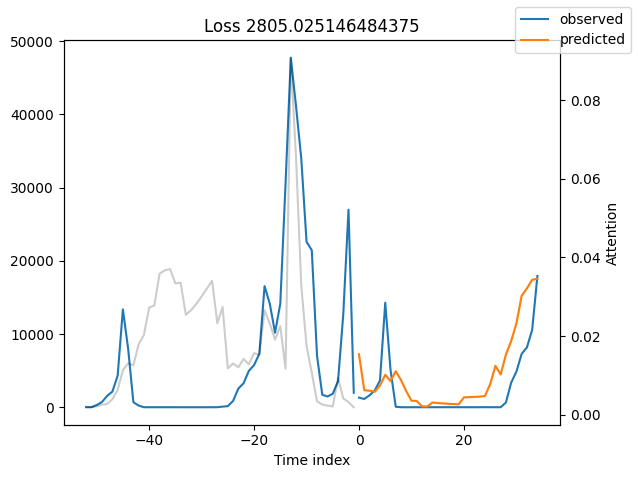

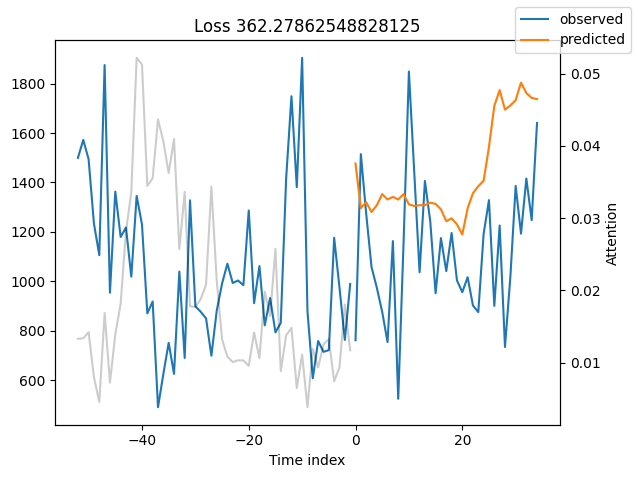

In [ ]:
raw = model.predict(val_loader, mode="raw", return_x=True)

# plot the first few series/windows
for idx in range(10):   # first 3 validation windows
    model.plot_prediction(
        raw.x,
        raw.output,
        idx=idx,
        add_loss_to_title=True,   # shows the loss for that window in the title
    )
    plt.show()

In [ ]:
wandb.finish()

**Filtering unimportant Features**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
holiday_drop = ['weeks_to_christmas', 'weeks_since_christmas','weeks_since_labor_day','super_bowl_phase_sin', 'weeks_to_thanksgiving',
'labor_day_phase_sin', 'weeks_to_super_bowl', 'christmas_phase_sin', 'labor_day_phase_cos', 'super_bowl_phase_cos']
features_drop = ['CPI', 'Fuel_Price', 'MarkDown1', 'MarkDown4', 'MarkDown2',
                 'MarkDown5', 'MarkDown3', 'Unemployment']
pipe = Pipeline([
    ('holiday_engineer', HolidayProximityTransformer()),
    ('calendar_feature_engineer', calendar_feature_engineer()),
    ('economic_indicator_imputer', EconomicIndicatorImputer()),
    ('markdown_imputer', MarkdownImputer()),
   ('to_categorical', ConvertToCategorical()),
    ('Date_processor', DateToTimeIdx()),
    ('drop_holiday', DropColumn(drop_cols=['IsHoliday_y', 'year', 'month', 'week', 'Week', 'Year', 'Month', 'Week', 'quarter',
                                           ] + holiday_drop + features_drop)),
    ('wmae_metric', WeightMetric())

])
train_df_t = pipe.fit_transform(train_df)
val_df_t = pipe.transform(val_df)
train_df_t.info()
val_df_t.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317928 entries, 0 to 421534
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Unnamed: 0                317928 non-null  int64         
 1   Store                     317928 non-null  category      
 2   Dept                      317928 non-null  category      
 3   Date                      317928 non-null  datetime64[ns]
 4   Weekly_Sales              317928 non-null  float64       
 5   IsHoliday_x               317928 non-null  category      
 6   Temperature               317928 non-null  float64       
 7   Type                      317928 non-null  category      
 8   Size                      317928 non-null  int64         
 9   weeks_since_super_bowl    317928 non-null  float64       
 10  weeks_to_labor_day        317928 non-null  float64       
 11  weeks_since_thanksgiving  317928 non-null  float64       
 12  thanksg

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
holiday_reals = ['weeks_since_super_bowl', 'weeks_to_labor_day', 'weeks_since_thanksgiving', 'thanksgiving_phase_sin', 'thanksgiving_phase_cos',
                 'christmas_phase_cos']
training = TimeSeriesDataSet(
    train_df_t,
    time_idx="time_idx",
    target="Weekly_Sales",
    group_ids=["Store", "Dept"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=["Store", "Dept", "Type"],
    static_reals=["Size"],

    time_varying_known_categoricals=["IsHoliday_x"],
    time_varying_known_reals=[
        "time_idx",
        "Temperature",

    ] + holiday_reals,

    time_varying_unknown_reals=["Weekly_Sales"],
    weight="wmae_weight",
    target_normalizer=GroupNormalizer(
        groups=["Store", "Dept"]
    ),

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,

    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    pd.concat([train_df_t, val_df_t], axis=0).reset_index(drop=True),
    predict=True,
    stop_randomization=True,
)

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 293 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__Store': '1', '__group_id__Dept': '51'}, {'__group_id__Store': '1', '__group_id__Dept': '77'}, {'__group_id__Store': '1', '__group_id__Dept': '78'}, {'__group_id__Store': '10', '__group_id__Dept': '51'}, {'__group_id__Store': '10', '__group_id__Dept': '77'}, {'__group_id__Store': '11', '__group_id__Dept': '48'}, {'__group_id__Store': '11', '__group_id__Dept': '50'}, {'__group_id__Store': '11', '__group_id__Dept': '51'}, {'__group_id__Store': '11', '__group_id__Dept': '77'}, {'__group_id__Store': '11', '__group_id__Dept': '78'}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/tim

In [ ]:
train_loader = training.to_dataloader(train=True, batch_size=128, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=128, num_workers=0)

**Training**

**Hyperparameter tuning**

In [ ]:
import optuna
import wandb
import lightning.pytorch as pl
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting.metrics import QuantileLoss

# explicit discrete grid — every combination gets trained
search_space = {
    "hidden_size": [48, 64],
    "hidden_continuous_size": [16, 32],   # kept <= min(hidden_size)=32 so no invalid combo
    "dropout": [0.2, 0.3],
    "learning_rate": [5e-5, 1e-4, 5e-4],
}
# total trials = 3 * 2 * 3 * 3 = 54


def objective(trial):
    hidden_size = trial.suggest_categorical("hidden_size", search_space["hidden_size"])
    model = TemporalFusionTransformer.from_dataset(
        training,
        hidden_size=hidden_size,
        hidden_continuous_size=trial.suggest_categorical(
            "hidden_continuous_size", search_space["hidden_continuous_size"]
        ),
        dropout=trial.suggest_categorical("dropout", search_space["dropout"]),
        learning_rate=trial.suggest_categorical("learning_rate", search_space["learning_rate"]),
        loss=QuantileLoss(),
    )
    wandb_logger = WandbLogger(project="walmart-sales-forecasting", group="TFT_grid_log1p",
                               name=f"trial_log1p-{trial.number}", log_model=False)
    trainer = pl.Trainer(
        max_epochs=15,
        gradient_clip_val=0.1,
        callbacks=[
            WMAECallback(),
            EarlyStopping(monitor="val_wmae", mode="min", patience=5),
        ],
        logger=wandb_logger,
        enable_progress_bar=True,
    )
    try:
        trainer.fit(model, train_loader, val_loader)
        score = trainer.callback_metrics["val_wmae"].item()
    finally:
        wandb.finish()
    return score


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.GridSampler(search_space),
)
study.optimize(objective)   # no n_trials → runs until the whole grid is exhausted

[I 2026-07-10 11:54:25,585] A new study created in memory with name: no-name-74773b41-56d9-4497-a94d-d163f91dd393
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  2.1 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    768 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 14.6 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 72.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 64.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 360 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 360 K                                                                                                
Total estimated model params size (MB): 1.441                                                                      
Modules in train mode: 491                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


epoch,▁▁▁
train_loss_step,█▃▁
trainer/global_step,▁▅█
epoch,0
train_loss_step,2.27575
trainer/global_step,149


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 469, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

**Log Transform on target**

In [ ]:
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

In [ ]:
train_df_t = train_df_t.copy()
train_df_t["Weekly_Sales"] = np.log1p(train_df_t["Weekly_Sales"].clip(lower=0))
val_df_t = val_df_t.copy()
val_df_t["Weekly_Sales"] = np.log1p(val_df_t["Weekly_Sales"].clip(lower=0))

In [ ]:
holiday_reals = ['weeks_since_super_bowl', 'weeks_to_labor_day', 'weeks_since_thanksgiving', 'thanksgiving_phase_sin', 'thanksgiving_phase_cos',
                 'christmas_phase_cos']
training = TimeSeriesDataSet(
    train_df_t,
    time_idx="time_idx",
    target="Weekly_Sales",
    group_ids=["Store", "Dept"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=["Store", "Dept", "Type"],
    static_reals=["Size"],

    time_varying_known_categoricals=["IsHoliday_x"],
    time_varying_known_reals=[
        "time_idx",
        "Temperature",

    ] + holiday_reals,

    time_varying_unknown_reals=["Weekly_Sales"],
    weight="wmae_weight",
    target_normalizer=GroupNormalizer(
        groups=["Store", "Dept"],
        transformation="log1p"
    ),

    add_relative_time_idx=True,

    add_encoder_length=True,

    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    pd.concat([train_df_t, val_df_t], axis=0).reset_index(drop=True),
    predict=True,
    stop_randomization=True,
)

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 293 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__Store': '1', '__group_id__Dept': '51'}, {'__group_id__Store': '1', '__group_id__Dept': '77'}, {'__group_id__Store': '1', '__group_id__Dept': '78'}, {'__group_id__Store': '10', '__group_id__Dept': '51'}, {'__group_id__Store': '10', '__group_id__Dept': '77'}, {'__group_id__Store': '11', '__group_id__Dept': '48'}, {'__group_id__Store': '11', '__group_id__Dept': '50'}, {'__group_id__Store': '11', '__group_id__Dept': '51'}, {'__group_id__Store': '11', '__group_id__Dept': '77'}, {'__group_id__Store': '11', '__group_id__Dept': '78'}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/tim

In [ ]:
train_loader = training.to_dataloader(train=True, batch_size=128, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=128, num_workers=0)

In [ ]:
print(list(training.target_normalizer.TRANSFORMATIONS.keys()))

['log', 'log1p', 'logit', 'count', 'softplus', 'relu', 'sqrt']


In [ ]:
print(training.target_normalizer.transformation)

log1p


In [ ]:
x, y = next(iter(train_loader))
print("y[0] (normalized target):", y[0].flatten()[:5])
print("  min/max/mean:", y[0].min().item(), y[0].max().item(), y[0].mean().item())
print("x decoder_target (RAW, expected thousands):", x["decoder_target"].flatten()[:5])

y[0] (normalized target): tensor([8.7020, 8.5829, 8.6967, 8.5875, 8.9545])
  min/max/mean: 0.0 12.407548904418945 8.479642868041992
x decoder_target (RAW, expected thousands): tensor([8.7020, 8.5829, 8.6967, 8.5875, 8.9545])


In [ ]:
import torch
import lightning.pytorch as pl


class WMAECallback(pl.Callback):
    def __init__(self):
        super().__init__()
        self.num = []
        self.den = []

    def on_validation_batch_end(
        self, trainer, pl_module, outputs, batch, batch_idx, dataloader_idx=0
    ):
        x, y = batch
        target = y[0]

        weights = y[1] if (len(y) > 1 and y[1] is not None) else torch.ones_like(target)

        with torch.no_grad():
            out = pl_module(x)
        pred = pl_module.to_prediction(out)

        weights = weights.to(pred)
        target = target.to(pred)

        # target and pred are in LOG space (log1p applied in the dataframe).
        # invert back to dollars BEFORE computing the weighted error.
        pred = torch.expm1(pred)
        target = torch.expm1(target)

        self.num.append((weights * (pred - target).abs()).sum().detach())
        self.den.append(weights.sum().detach())

    def on_validation_epoch_end(self, trainer, pl_module):
        score = torch.stack(self.num).sum() / torch.stack(self.den).sum()
        pl_module.log("val_wmae", score, prog_bar=True, logger=True)
        self.num.clear()
        self.den.clear()